In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1, erfc
from cascade_functions import _gs95_turbulence, hourglass_field_gs95, compare_kolmo_vs_gs95, hourglass_field_kolmo


## Call Functions

Running Kolmogorov model...
Running GS95 model...
[GS95] M_A=0.50  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=4.00  aniso_ratio=4.2267  (<1 = par suppressed)


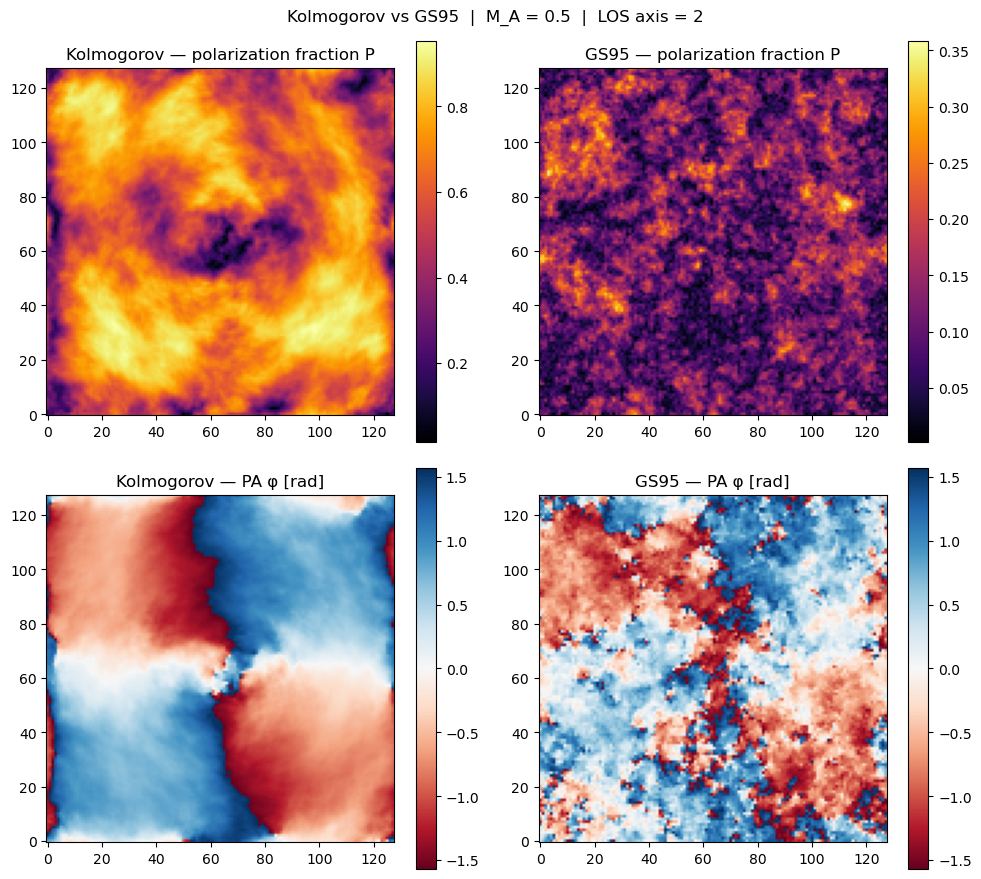


  Mean P  :  Kolmogorov = 0.6388   GS95 = 0.1146
  Std  P  :  Kolmogorov = 0.1794    GS95 = 0.0572
  Mean cg :  Kolmogorov = 0.0249   GS95 = 0.1941


In [4]:
# P, phi, cg = hourglass_field_gs95(M_A=0.1, g_size=64, iaxis=2, plotting=True, alfven_fraction=0.6, 
#                                   slow_fraction=0.2,fast_fraction=0.2,anisotropy_strength=0, seed=42)

# print(f"Mean polarization fraction: {P.mean():.4f}")
# print(f"Mean depolarization cos²γ:  {cg.mean():.4f}")

# plt.hist(P.flatten(), bins=50, alpha=0.7)
# plt.title('Polarization fraction')

compare_kolmo_vs_gs95(M_A=0.5, g_size=128, iaxis=2)


[GS95] M_A=0.20  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=25.00  aniso_ratio=3.8994  (<1 = par suppressed)
[GS95] M_A=0.30  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=11.11  aniso_ratio=4.0485  (<1 = par suppressed)
[GS95] M_A=0.40  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=6.25  aniso_ratio=4.1527  (<1 = par suppressed)
[GS95] M_A=0.50  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=4.00  aniso_ratio=4.2267  (<1 = par suppressed)
[GS95] M_A=0.75  regime=weak→GS95 (sub-Alfvenic, L06)  k_trans/k_box=1.78  aniso_ratio=4.3401  (<1 = par suppressed)
[GS95] M_A=1.00  regime=hydro→GS95 (super-Alfvenic, L06)  k_trans/k_box=1.00  aniso_ratio=0.1529  (<1 = par suppressed)
[GS95] M_A=1.50  regime=hydro→GS95 (super-Alfvenic, L06)  k_trans/k_box=3.37  aniso_ratio=0.2414  (<1 = par suppressed)
[GS95] M_A=2.00  regime=hydro→GS95 (super-Alfvenic, L06)  k_trans/k_box=8.00  aniso_ratio=0.3167  (<1 = par suppressed)
[GS95] M_A=3.00  regime=hydro→GS95 (super-Alfvenic, L

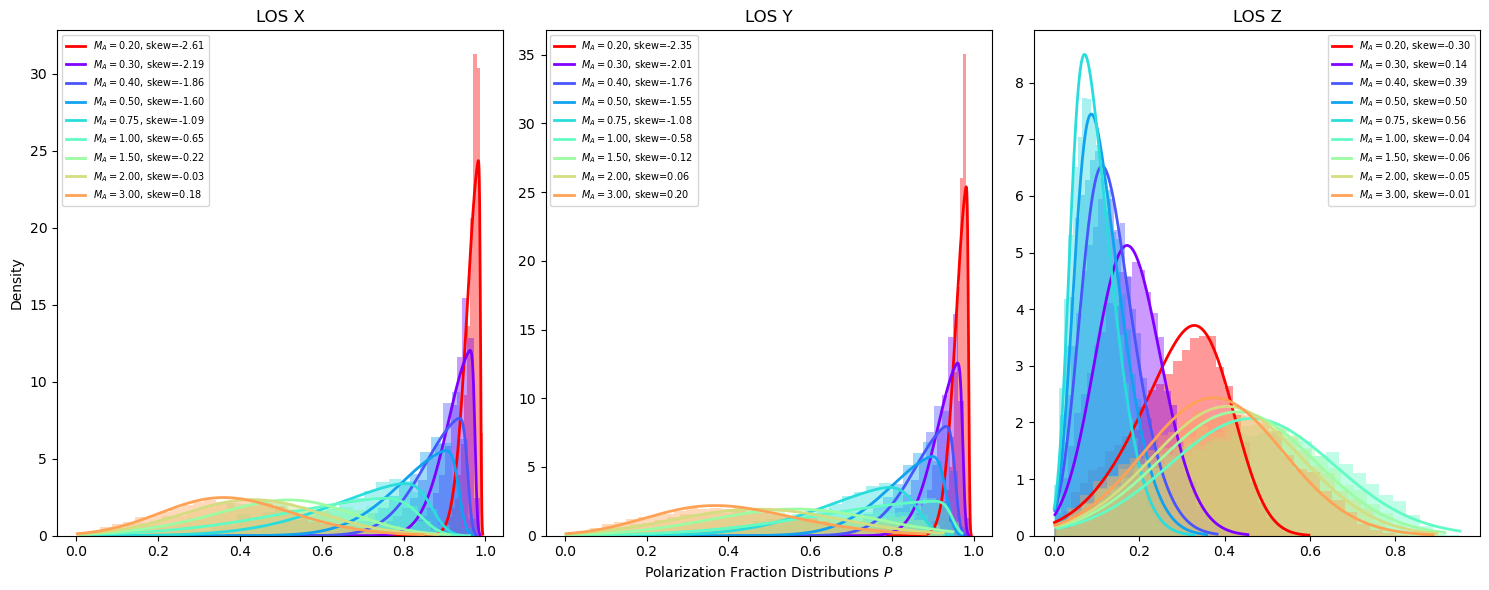

In [5]:
from scipy.stats import skew, skewnorm
# mach_vals = [0,0.01,0.02,0.05]
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

fig, axes = plt.subplots(1,3,figsize=(15,6))

for nax in range(3):
    for imach in mach_vals:

        # simulate
        P, PHI, COS = hourglass_field_gs95(M_A=imach, g_size=128, iaxis=nax, plotting=False, anisotropy_strength=1.0, seed=42)

        # flatten & clip to >0
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]

        # --- compute raw skewness ---
        skew_val = skew(Pflat, bias=False)

        # --- fit skewnormal distribution ---
        # skewnorm.fit returns (a, loc, scale)
        a, loc, scale = skewnorm.fit(Pflat)

        # build PDF for plotting
        x = np.linspace(Pflat.min(), Pflat.max(), 300)
        pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

        # --- histogram ---
        axes[nax].hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # --- overlay skewnormal fit ---
        axes[nax].plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

    axes[nax].legend(fontsize=7)

axes[1].set_xlabel("Polarization Fraction Distributions $P$")
axes[0].set_ylabel("Density")
axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')
# axes[0].yscale("log")
# axes[0].set_ylim(0,2000)
# axes[1].set_ylim(0,6000)
# axes[2].set_ylim(0,1e4)
# plt.title('Uniform Field: Polarization Distributions for Varying Mach #')
plt.tight_layout()
plt.show()
